# 1. 의사결정나무

    * 의사결정 나무모델
        - 지도학습 알고리즘 (분류, 회귀)
        - 직관적인 알고리즘 (이해 쉬움)
        - 과대적합되기 쉬운 알고리즘 (트리 깊이 제한 필요)

In [1]:
# 요한 라이브러리를 가져오고, sklearn 라이브러리에 내장된 데이터를 불러옵니다.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## 데이터 불러오기

In [2]:
# 데이터 생성
from sklearn.datasets import load_breast_cancer

def make_dataset():
    iris = load_breast_cancer()
    df = pd.DataFrame(iris.data, columns=iris.feature_names)
    df['target'] = iris.target
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop('target', axis=1), df['target'], test_size=0.5, random_state=1004)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = make_dataset()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((284, 30), (285, 30), (284,), (285,))

In [3]:
# 타겟 확인
y_train.value_counts()

target
1    190
0     94
Name: count, dtype: int64

## **의사결정나무**
* 지도학습(분류)에서 가장 유용하게 사용되고 있는 기법 중 하나임
* 트리의 루트(root)에서 시작해서 정보이득이 최대가 되는 특성으로 데이터를 나눔
* 정보이득 (Infomation gain)이 최대가 되는 특성을 나누는 기준 (불순도를 측정하는 기준)은 '지니'와 '엔트로피'가 사용된다.
    - 데이터가 한 종류만 있다면 엔트로피/지니 불순도는 0에 가깝다 서로 다른 데이터의 비율이 비슷하면 1에 가까움
    - 정보이득 (Information gain)이 최대라는 것은 불순도를 최소화 하는 방향이다 (1-불순도)

* **용어설명**
* 지니 : 데이터를 무작위로 뽑았을 때 잘못 분류될 확률
* 엔트로피 : 불확실성 (정보의 혼란도)를 측정함
* 지니와 엔트로피는 불순도의 척도이며 쉽게 말해 노드 안에 섞여 있는 클래스들이 얼마나 뒤섞여 있는지를 나타내는 지표


In [4]:
# 의사결정나무

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state = 0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)

0.9263157894736842

### **의사결정나무 하이퍼파라미터**

* criterion(기본값 gini) : 불순도 지표 ( 또는 엔트로피 불순도 entropy)
* max_depth(기본값 None) : 최대 한도 깊이
* max_leaf_nodes(기본값 None) : 리프 노드의 최대 개수
* min_samples_split (기본값 2) : 자식 노드를 갖기 위한 최소한의 데이터 수
* min_samples_leaf (기본값 1) : 리프 노드가 되기 위한 최소 샘플 수 (리프 노드 : 제일 마지막에 있는 노드)

In [5]:
# 의사결정나무 하이퍼파라미터 (max_depth 설정하기)
# 기본적으로 DecisionTreeClassifier에는 max_depth 한도 제한이 없기 때문에 오퍼피팅이 나는 경우도 있다.
# 그래서 max_depth를 제한하는 경우도 있다.

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth = 3, random_state = 0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)

0.9087719298245615

In [6]:
# 의사결정나무 하이퍼파라미터 (min_samples_leaf 설정하기)
# 기본적인 세팅을 이용할 수도 있지만 기본값을 수정해서 사용할 수도 있다는것을 학습하면 좋다.

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 2, random_state = 0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)

0.9052631578947369

In [7]:
# criterion를 이용한 의사결정나무

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'entropy', 
                               max_depth = 3, 
                               min_samples_leaf = 2, 
                               random_state = 0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)

0.9122807017543859

In [8]:
# min_samples_split를 이용한 의사결정나무

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'entropy', 
                               max_depth = 3, 
                               min_samples_split = 6,
                               min_samples_leaf = 2, 
                               random_state = 0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)

0.9122807017543859

## **랜덤포레스트**

* 여러개의 의사결정 트리로 구성
* 앙상블 방법 중 배깅(bagging) 방식
* 부트스트랩 샘플링 (데이터셋 중복 허용)
* 최종 다수결 투표

* 지도학습 알고리즘 (분류, 회귀)
* 의사결정나무의 앙상블
* 여러 개의 의사결정 트리로 구성
* 성능이 좋음 (과대적합 가능성 낮음)
* 부트스트랩 생플링 (데이터셋 중복 허용)
* 최종 다수결 투표
* 앙상블
    * 배깅 : 같은 알고리즘으로 여러 모델을 만들어 분류함 (랜덤포레스트)
    * 부스팅 : 학습과 예측을 하면서 가중치 반영

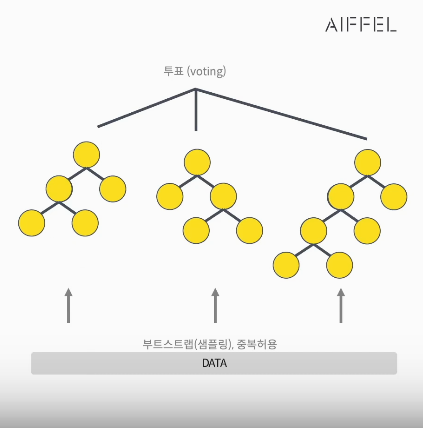

In [9]:
# 랜덤포레스트
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state = 0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)

0.9438596491228071

#### **랜덤포레스트 하이퍼파라미터**

* n_estimators (기본값 100) : 트리의 수
* criterion (기본값 gini) : 불순도 지표
* max_depth (기본값 None) : 최대 한도 깊이
* min_samples_split (기본값 2) : 자식 노드를 갖기 위한 최소한의 데이터 수
* min_samples_leaf (기본값 1) : 리프 노드가 되기 위한 최소 샘플 수

In [10]:
# 랜덤포레스트 하이퍼파라미터 n_estimators 설정하기

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 200, random_state = 0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)

0.9473684210526315

In [11]:
# 랜덤포레스트 하이퍼파라미터 max_depth 고정해보기

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 200, max_depth = 5, random_state = 0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)
# 0.9473684210526315 max_depth = 3
# 0.9157894736842105 max_depth = 1

0.9473684210526315

## **xgboost**

**XGBoost 모델 더 알아보기**

* 트리 앙상블 중 성능이 좋은 알고리즘
* eXtreme Gradient Boosting를 줄여서 XGBoost라고 한다.
* 약한 학습기가 계속해서 업데이트를 하며 좋은 모델을 만들어 간다.
* 부스팅(앙상블) 기반의 알고리즘 - 트리 앙상블 중 성능이 좋은 알고리즘
* 캐글(글로벌 AI 경진대회)에서 뛰어난 성능을 보이면서 인기가 높아짐

In [12]:
# xgboost 설치

!pip install xgboost

In [13]:
# xgboost
from xgboost import XGBClassifier

model = XGBClassifier(random_state = 0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)

0.9508771929824561

**XGBoost 하이퍼파라미터**

* booster (기본값 gbtree) : 부스팅 알고리즘 (또는 dart, gblinear)
* objective (기본값 binary:logistic) : 이진분류 (다중분류: multi:softmax)
* max_depth (기본값 6) : 최대 한도 깊이
* learning_rate (기본값 0.1) : 학습률
* n_estimators (기본값 100) : 트리의 수
* subsample (기본값 1) : 훈련 샘플 개수의 비율
* colsample_bytree (기본값 1) : 특성 개수의 비율
* n_jobs (기본값 1) : 사용 코어 수 (-1: 모든 코어를 다 사용)

 **주의점** : learning_rate 값을 더 촘촘하게 보기위해 낮췄다면 n_estimators의 값은 올려줘야한다. 트리의 갯수가 모자라면 멈추기 때문에.

In [14]:
# xgboost 하이퍼파라미터 max_depth 와 n_jobs를 튜닝해보기

model = XGBClassifier(random_state = 0,
                      booster = 'gbtree',
                      objective = 'binary:logistic',
                      max_depth = 5,
                      learning_rate = 0.1,
                      n_estimators = 100,
                      subsample = 1,
                      colsample_bytree = 1,
                      n_jobs = -1
                     )
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)

0.9614035087719298

In [15]:
# xgboost 하이퍼파라미터 n_estimators, learning_rate 추가적으로 튜닝하기

model = XGBClassifier(random_state = 0,
                      booster = 'gbtree',
                      objective = 'binary:logistic',
                      max_depth = 5,
                      learning_rate = 0.07,
                      n_estimators = 200,
                      subsample = 1,
                      colsample_bytree = 1,
                      n_jobs = -1
                     )
model.fit(X_train, y_train)
pred = model.predict(X_test)

#평가
accuracy_score(y_test, pred)

0.9614035087719298

In [16]:
# # 조기종료 (버전을 낮춰서 다시한번 해보기 1.7.0 버전 이상에서는 실행이 안됨)
# # n_estimators 에서 500이 되기전에 좋은 값이 나오면 조기종료할 수 있게 하기

# model = XGBClassifier(random_state = 0,
#                       learning_rate = 0.07,
#                       n_estimators = 200,
#                       eval_metric='logloss')

# # 검증할 테이터 셋
# eval_set = [(X_test, y_test)] 

# # 학습할 때 검증까지 넣어줌 + 조기종료 값(early_stopping_rounds)을 넣어준다. 
# model.fit(X_train, y_train, eval_set = eval_set, early_stopping_rounds = 10,verbose=True) # 10번이상 성능향상이 없다면 종료해라.
# pred = model.predict(X_test)

# #평가
# accuracy_score(y_test, pred)

## **교차검증**

#### **Kfold**

* 일반적으로 사용되는 교차 검증 기법

In [17]:
# 데이터셋 로드
def make_dataset2():
    iris = load_breast_cancer()
    df = pd.DataFrame(iris.data, columns=iris.feature_names)
    df['target'] = iris.target
    return df.drop('target', axis=1), df['target']
X, y = make_dataset2()

In [18]:
# KFold
from sklearn.model_selection import KFold
model = DecisionTreeClassifier(random_state = 0)

kfold = KFold(n_splits = 5)
for train_idx, test_idx in kfold.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
           
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    #평가
    print(accuracy_score(y_test, pred))

0.8771929824561403
0.9122807017543859
0.9473684210526315
0.9385964912280702
0.8407079646017699


#### **StratifiedKfold**
* 불균형한 타겟 비율을 가진 데이터가 한쪽으로 치우치는 것을 방지

In [19]:
# Stratified Kfold
from sklearn.model_selection import StratifiedKFold
model = DecisionTreeClassifier(random_state = 0)

kfold = StratifiedKFold(n_splits = 5)
for train_idx, test_idx in kfold.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
           
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    #평가
    print(accuracy_score(y_test, pred))

0.9035087719298246
0.9210526315789473
0.9122807017543859
0.9473684210526315
0.9026548672566371


#### **사이킷런 교차검증** (편리함)
* 사이킷런 내부 API를 통해 fit(학습) - predict(예측) - evaluation(평가)

In [20]:
#교차검증
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv = 3)
scores

array([0.88947368, 0.94210526, 0.86243386])

In [21]:
# 평균점수
scores.mean()

0.8980042699340944

In [22]:
# 교차검증 Stratified Kfold (사이킷런 내부 API를 통해 stratified로 교차검증)
kfold = StratifiedKFold(n_splits = 5)
scores = cross_val_score(model, X, y, cv = kfold)
scores

array([0.90350877, 0.92105263, 0.9122807 , 0.94736842, 0.90265487])

In [23]:
# 평균점수
scores.mean()

0.9173730787144851

## **평가 (분류)**

* 정확도 Accuracy : 실제값과 예측값이 일치 비율
* 정밀도 precision : 양성이라고 예측한 값 중 실제 양성인 값 ( 암이라고 예측 한 값 중 실제 암일 확률 )
* 재현율 recall : 실제 양성 값 중 양성으로 예측한 값 ( 실제 암인 값 중 예측도 암인 확률 )
* **참고** 정밀도와 재현율은 트레이드오프관계 한쪽이 올라가면 한쪽이 떨어지는 관계
* F1 : 정밀도와 재현율 조화 평균
* ROC-AUC
  - ROC : 참 양성 비율 (True Positive Rate)에 대한 거짓 양성 비율 (False Positive Rate)곡선 > 곡선이 위로가면 갈수록 좋음
  - AUC : ROC 곡선 면적 아래 ( 완벽하게 분류되면 AUC가 1이다. )
  - 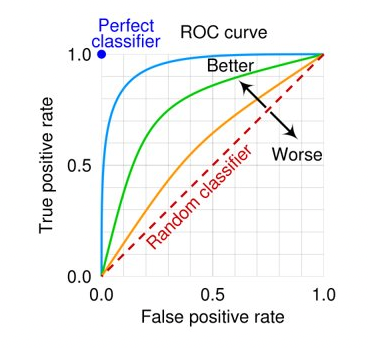

In [24]:
# 정확도
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred)

0.9026548672566371

In [25]:
# 정밀도
from sklearn.metrics import precision_score

precision_score(y_test, pred)

0.9545454545454546

In [26]:
# 정밀도

from sklearn.metrics import recall_score

recall_score(y_test, pred)

0.8873239436619719

In [27]:
# 정밀도
from sklearn.metrics import f1_score

f1_score(y_test, pred)

0.9197080291970803

In [28]:
# roc_auc
from sklearn.metrics import roc_auc_score

model = XGBClassifier(random_state = 0)
model.fit(X_train, y_train)
pred = model.predict_proba(X_test) # pfrom sklearn.metrics import f1_scoreroba를 넣어주면 확률값으로 반환해준다.
pred

roc_auc_score(y_test, pred[:,1])

0.999664654594232